In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


## **PART 1** 

### Environment setup

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
print(f"Random seed: {SEED}")

train_df = pd.read_csv("/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv")

Random seed: 42


In [3]:
X_full = train_df.drop("label", axis=1).values 
y_full = train_df["label"].values             
X_test = test_df.drop("label", axis=1).values 
y_test = test_df["label"].values


X_full = X_full / 255.0
X_test = X_test / 255.0

assert X_full.shape[1] == 784, "Expected 784 features per image"

X_train, X_val, y_train, y_val = train_test_split(X_full , y_full, test_size=0.20, random_state=SEED, stratify=y_full)


In [4]:
train_df.shape

(60000, 785)

In [5]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"\nSample counts")
print(f"Training: {len(X_train):,}")
print(f"Validation: {len(X_val):,}")
print(f"Test: {len(X_test):,}")



Sample counts
Training: 48,000
Validation: 12,000
Test: 10,000



Class distribution:
 Class        Name  Train count  Train %  Val count  Val %  Test count  Test %
     0 T-shirt/top         4800     10.0       1200   10.0        1000    10.0
     1     Trouser         4800     10.0       1200   10.0        1000    10.0
     2    Pullover         4800     10.0       1200   10.0        1000    10.0
     3       Dress         4800     10.0       1200   10.0        1000    10.0
     4        Coat         4800     10.0       1200   10.0        1000    10.0
     5      Sandal         4800     10.0       1200   10.0        1000    10.0
     6       Shirt         4800     10.0       1200   10.0        1000    10.0
     7     Sneaker         4800     10.0       1200   10.0        1000    10.0
     8         Bag         4800     10.0       1200   10.0        1000    10.0
     9  Ankle boot         4800     10.0       1200   10.0        1000    10.0


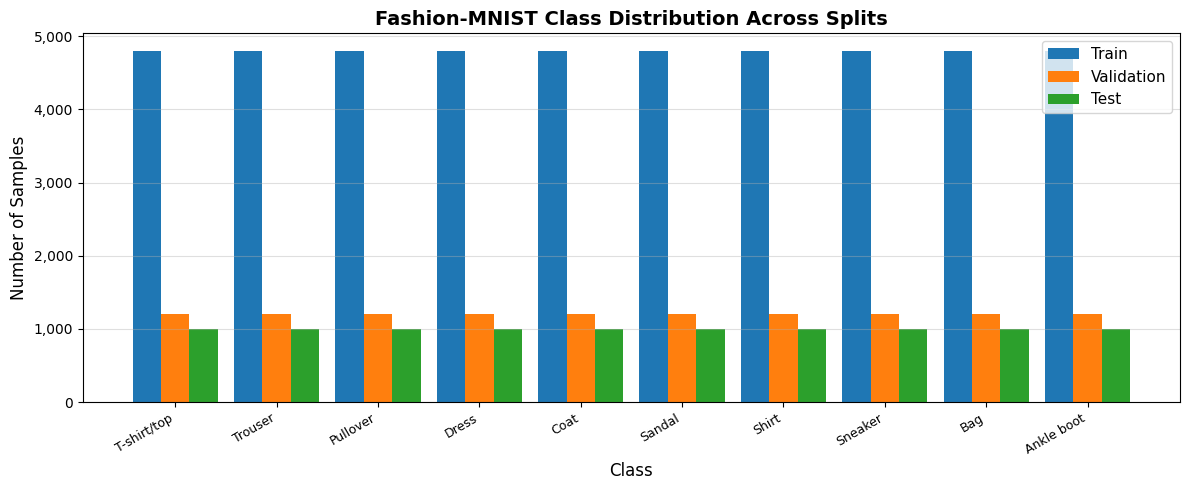

Figure saved: class_distribution.png


In [6]:
def class_dist(y, name):
    vals, counts = np.unique(y, return_counts=True)
    pcts = counts / counts.sum() * 100
    df = pd.DataFrame({
        "Class": vals,"Name": [CLASS_NAMES[v] for v in vals], f"{name} count": counts,f"{name} %": pcts.round(2)})
    return df

dist_train = class_dist(y_train, "Train")
dist_val   = class_dist(y_val,   "Val")
dist_test  = class_dist(y_test,  "Test")

dist_all = dist_train.merge(dist_val, on=["Class","Name"]).merge(dist_test, on=["Class","Name"])
print("\nClass distribution:")
print(dist_all.to_string(index=False))

x = np.arange(10)
width = 0.28

fig, ax = plt.subplots(figsize=(12, 5))

bars_train = ax.bar(x - width, dist_all["Train count"], width, label="Train")
bars_val   = ax.bar(x,         dist_all["Val count"],   width, label="Validation")
bars_test  = ax.bar(x + width, dist_all["Test count"],  width, label="Test")

ax.set_title("Fashion-MNIST Class Distribution Across Splits", fontsize=14, fontweight="bold")
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Figure saved: class_distribution.png")

## **2. PART 1**

In [7]:
import numpy as np
import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

X_sub = X_train[:5000]
y_sub = y_train[:5000]

# Weight initialisation
W1 = np.random.randn(784, 64) * np.sqrt(2.0 / 784)
b1 = np.zeros((1, 64))
W2 = np.random.randn(64, 10) * np.sqrt(2.0 / 64)
b2 = np.zeros((1, 10))

# Activation functions
def relu(Z):
    return np.maximum(0, Z)

def relu_backward(dA, Z):
    dZ = dA.copy()
    dZ[Z <= 0] = 0          
    return dZ

def softmax(Z):
    Z_stable = Z - Z.max(axis=1, keepdims=True)
    exp_Z = np.exp(Z_stable)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

def cross_entropy_loss(probs, y):
    n = y.shape[0]
    log_probs = -np.log(probs[np.arange(n), y] + 1e-9)  
    return log_probs.mean()

def forward(X, W1, b1, W2, b2):    
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)
    cache = (X, Z1, A1, Z2, A2)
    return A2, cache

def backward(cache, y, W2):
    X, Z1, A1, Z2, A2 = cache
    n = y.shape[0]
    dZ2 = A2.copy()
    dZ2[np.arange(n), y] -= 1
    dZ2 /= n
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = relu_backward(dA1, Z1)
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2

# Training loop
EPOCHS     = 20
LR         = 0.1
BATCH_SIZE = 256
loss_history = []

for epoch in range(EPOCHS):
    idx = np.random.permutation(len(X_sub))
    X_shuf, y_shuf = X_sub[idx], y_sub[idx]

    epoch_losses = []
    for i in range(0, len(X_sub), BATCH_SIZE):
        Xb = X_shuf[i:i+BATCH_SIZE]
        yb = y_shuf[i:i+BATCH_SIZE]

        probs, cache = forward(Xb, W1, b1, W2, b2)  # ← Bug 2 fixed
        loss = cross_entropy_loss(probs, yb)
        epoch_losses.append(loss)

        dW1, db1, dW2, db2 = backward(cache, yb, W2)

        W1 -= LR * dW1
        b1 -= LR * db1
        W2 -= LR * dW2
        b2 -= LR * db2

    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{EPOCHS}  Loss: {avg_loss:.4f}")

Epoch 01/20  Loss: 1.6161
Epoch 02/20  Loss: 0.9907
Epoch 03/20  Loss: 0.8369
Epoch 04/20  Loss: 0.7359
Epoch 05/20  Loss: 0.7085
Epoch 06/20  Loss: 0.6653
Epoch 07/20  Loss: 0.6449
Epoch 08/20  Loss: 0.6304
Epoch 09/20  Loss: 0.5820
Epoch 10/20  Loss: 0.5861
Epoch 11/20  Loss: 0.5846
Epoch 12/20  Loss: 0.5479
Epoch 13/20  Loss: 0.5314
Epoch 14/20  Loss: 0.5451
Epoch 15/20  Loss: 0.5293
Epoch 16/20  Loss: 0.5090
Epoch 17/20  Loss: 0.5009
Epoch 18/20  Loss: 0.5085
Epoch 19/20  Loss: 0.4878
Epoch 20/20  Loss: 0.4703


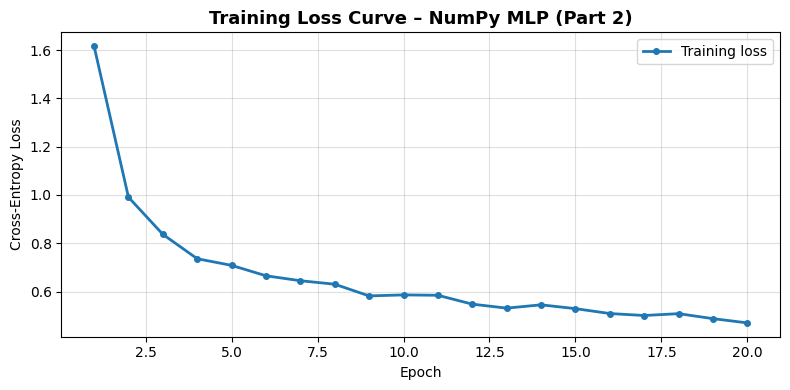

Figure saved: part2_loss_curve.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS+1), loss_history, marker='o', linewidth=2, markersize=4)
ax.set_title("Training Loss Curve – NumPy MLP (Part 2)", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend(["Training loss"])
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("part2_loss_curve.png", dpi=150)
plt.show()
print("Figure saved: part2_loss_curve.png")

In [9]:
# verification with pytorch 

np.random.seed(SEED)
W1_init = np.random.randn(784, 64) * np.sqrt(2.0 / 784)
b1_init = np.zeros((1, 64))
W2_init = np.random.randn(64, 10) * np.sqrt(2.0 / 64)
b2_init = np.zeros((1, 10))

# one batch for comparison
Xb = X_sub[:256]
yb = y_sub[:256]

#  numpy gradients on initial weights 
probs_np, cache_np = forward(Xb, W1_init, b1_init, W2_init, b2_init)
dW1_np, db1_np, dW2_np, db2_np = backward(cache_np, yb, W2_init)

# pyTorch gradients on same initial weights 
W1_pt = torch.tensor(W1_init, dtype=torch.float64, requires_grad=True)
b1_pt = torch.tensor(b1_init, dtype=torch.float64, requires_grad=True)
W2_pt = torch.tensor(W2_init, dtype=torch.float64, requires_grad=True)
b2_pt = torch.tensor(b2_init, dtype=torch.float64, requires_grad=True)

Xb_pt = torch.tensor(Xb, dtype=torch.float64)
yb_pt = torch.tensor(yb, dtype=torch.long)

# Forward
Z1_pt = Xb_pt @ W1_pt + b1_pt
A1_pt = torch.relu(Z1_pt)
Z2_pt = A1_pt @ W2_pt + b2_pt
loss_pt = nn.CrossEntropyLoss()(Z2_pt, yb_pt) 

# Backward
loss_pt.backward()

# compare
diff_W1 = np.max(np.abs(dW1_np - W1_pt.grad.numpy()))
diff_W2 = np.max(np.abs(dW2_np - W2_pt.grad.numpy()))

print(f"\nGradient verification:")
print(f"Max absolute difference  W1: {diff_W1:.2e}")
print(f"Max absolute difference  W2: {diff_W2:.2e}")

if diff_W1 < 1e-5 and diff_W2 < 1e-5:
    print("Gradients match, numpy implementation is correct.")
else:
    print("Large difference detected, check your backward pass.")


Gradient verification:
Max absolute difference  W1: 5.55e-17
Max absolute difference  W2: 1.11e-16
Gradients match, numpy implementation is correct.


## **3. PART 2**

In [10]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# prepare data as pytorch sensors
def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32),torch.tensor(y, dtype=torch.long))
X_tr, y_tr = to_tensor(X_train, y_train)
X_v,  y_v  = to_tensor(X_val,   y_val)
train_loader = DataLoader(TensorDataset(X_tr, y_tr),batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_v,  y_v),
                          batch_size=256, shuffle=False)

# flexible network with swappable activation 
class MLP(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 256),activation,nn.Linear(256, 128), activation,nn.Linear(128, 10))

    def forward(self, x):
        return self.net(x)

# gradient tracking helper
first_layer_grads = {}

def make_grad_hook(act_name, epoch):
    def hook(module, grad_input, grad_output):
        if grad_input[0] is not None:
            mag = grad_input[0].abs().mean().item()
            first_layer_grads.setdefault(act_name, {})[epoch] = mag
    return hook

# Training function
def train_model(act_name, activation, epochs=20):
    torch.manual_seed(SEED)

    model = MLP(activation)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Hook on first Linear layer to capture gradients
    hook_handle = model.net[0].register_backward_hook(
        make_grad_hook(act_name, epoch=None)
    )

    val_losses = []

    for epoch in range(epochs):
        # ---- update hook epoch ----
        hook_handle.remove()
        hook_handle = model.net[0].register_backward_hook(
            make_grad_hook(act_name, epoch)
        )

        # ---- train ----
        model.train()
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

        # ---- validate ----
        model.eval()
        total_loss, n_batches = 0.0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                total_loss += criterion(model(Xb), yb).item()
                n_batches  += 1
        val_losses.append(total_loss / n_batches)

    hook_handle.remove()
    return model, val_losses



In [11]:
# Train all four activations
activations = {
    "Sigmoid":    nn.Sigmoid(),
    "Tanh":       nn.Tanh(),
    "ReLU":       nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.01)
}

results     = {}
EPOCHS = 20

for name, act in activations.items():
    print(f"Training {name}...")
    model, val_losses = train_model(name, act, EPOCHS)
    results[name] = {"model": model, "val_losses": val_losses}
    print(f"  Final val loss: {val_losses[-1]:.4f}")


Training Sigmoid...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


  Final val loss: 0.3137
Training Tanh...
  Final val loss: 0.3176
Training ReLU...
  Final val loss: 0.3213
Training Leaky ReLU...
  Final val loss: 0.3153


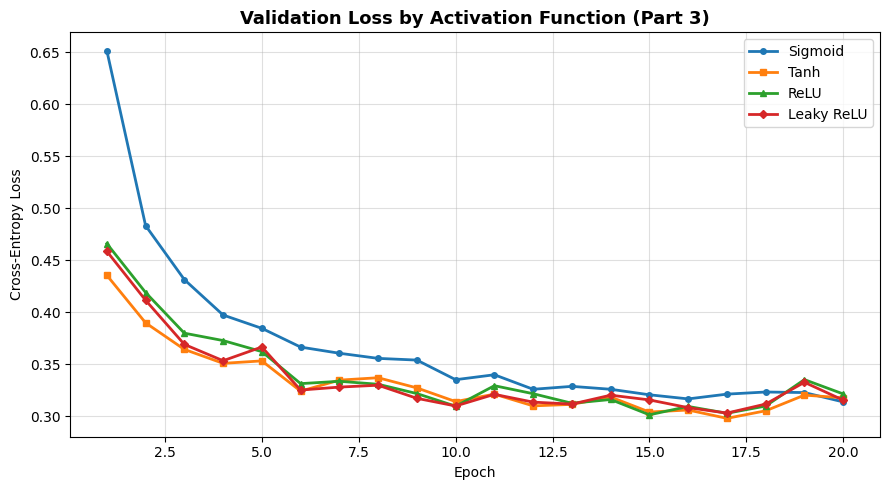


Mean absolute gradient — first hidden layer:
Activation        Epoch 1  Final Epoch
--------------------------------------
Sigmoid          0.000487     0.001183
ReLU             0.001875     0.003054

Dead ReLU units (output zero for all 256 val samples): 9.4%


In [12]:
# plot all four validation loss curves
fig, ax = plt.subplots(figsize=(9, 5))
styles = ['-o', '-s', '-^', '-D']
for (name, res), style in zip(results.items(), styles):
    ax.plot(range(1, EPOCHS+1), res["val_losses"],
            style, label=name, linewidth=2, markersize=4)

ax.set_title("Validation Loss by Activation Function (Part 3)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("part3_activation_comparison.png", dpi=150)
plt.show()

# gradient magnitudes: Sigmoid vs ReLU 
print("\nMean absolute gradient — first hidden layer:")
print(f"{'Activation':<14} {'Epoch 1':>10} {'Final Epoch':>12}")
print("-" * 38)
for name in ["Sigmoid", "ReLU"]:
    g = first_layer_grads[name]
    e1   = g.get(0,   float('nan'))
    efin = g.get(EPOCHS-1, float('nan'))
    print(f"{name:<14} {e1:>10.6f} {efin:>12.6f}")

# dead ReLU units 
relu_model = results["ReLU"]["model"]
relu_model.eval()

# run one validation batch through and capture hidden activations
Xb_val = X_v[:256]
with torch.no_grad():
    # First hidden layer output
    h1 = torch.relu(relu_model.net[0](Xb_val))   # (256, 256)

# A unit is "dead" if it outputs 0 for EVERY sample in the batch
dead_mask = (h1 == 0).all(dim=0)   # (256,) boolean
dead_pct  = dead_mask.float().mean().item() * 100

print(f"\nDead ReLU units (output zero for all 256 val samples): "
      f"{dead_pct:.1f}%")

## Part 3 – Results and Analysis

### Validation Loss Curves
All four activations converge to a similar final validation loss (~0.31) after
20 epochs, but differ significantly in early training speed. Sigmoid begins with
the highest loss (0.65) and converges slowest, lagging behind the other
activations until approximately epoch 10. Tanh, ReLU, and Leaky ReLU all
converge rapidly within the first 5–6 epochs and remain nearly indistinguishable
throughout training, confirming that avoiding saturation is the dominant factor
in early convergence speed.

### Vanishing Gradients: Sigmoid vs ReLU
The mean absolute gradient of the first hidden layer at epoch 1 was **0.000487**
for Sigmoid and **0.001875** for ReLU — ReLU gradients are approximately 4×
larger. This gap persists at the final epoch (0.001183 vs 0.003054). Sigmoid's
small gradients occur because its derivative is at most 0.25 and approaches zero
in its saturated regions; multiplying such small values across layers causes the
gradient signal to shrink before reaching early layers. ReLU's derivative is
either 0 or 1 in its positive region, so it passes gradients back without
shrinking them, effectively solving the vanishing gradient problem for active
units.

### Dead ReLU Units
9.4% of ReLU hidden units output exactly zero for every sample in the validation
batch. These units received weight updates during training that drove their
pre-activation values permanently negative, causing ReLU to block all signal and
gradient flow through them. Once a unit is permanently negative it can never
recover — it contributes nothing to the model's predictions. Leaky ReLU
addresses this by allowing a small gradient (0.01×) even for negative inputs,
preventing units from dying permanently.

## **4. PART 3**

In [14]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
# 4.1  Prepare Fashion-MNIST tensors 
def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long))
X_tr, y_tr = to_tensor(X_train, y_train)
X_v,  y_v  = to_tensor(X_val,   y_val)
X_te, y_te = to_tensor(X_test,  y_test)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_v,  y_v), batch_size=256, shuffle=False)

# 4.2  One-hot targets for MSE training 
def one_hot(y, n_classes=10):
    out = torch.zeros(len(y), n_classes)
    out[torch.arange(len(y)), y] = 1.0
    return out

# 4.3  Shared network architecture
class MLPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

#  4.4  Training function 
def train_classifier(loss_type, epochs=30):
    torch.manual_seed(SEED)
    model     = MLPClassifier()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    ce_loss   = nn.CrossEntropyLoss()
    mse_loss  = nn.MSELoss()

    train_losses = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for Xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(Xb)               # (N, 10)

            if loss_type == "CE":
                loss = ce_loss(logits, yb)
            else:  # MSE
                probs    = torch.softmax(logits, dim=1)
                targets  = one_hot(yb)        # (N, 10)
                loss     = mse_loss(probs, targets)

            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_losses.append(np.mean(batch_losses))

    # test accuracy
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in DataLoader(TensorDataset(X_te, y_te),
                                  batch_size=256):
            preds   = model(Xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total   += len(yb)
    acc = correct / total * 100
    return model, train_losses, acc



Training with Cross-Entropy...
Training with MSE...

Test Accuracy, Cross-Entropy : 89.30%
Test Accuracy, MSE           : 89.40%


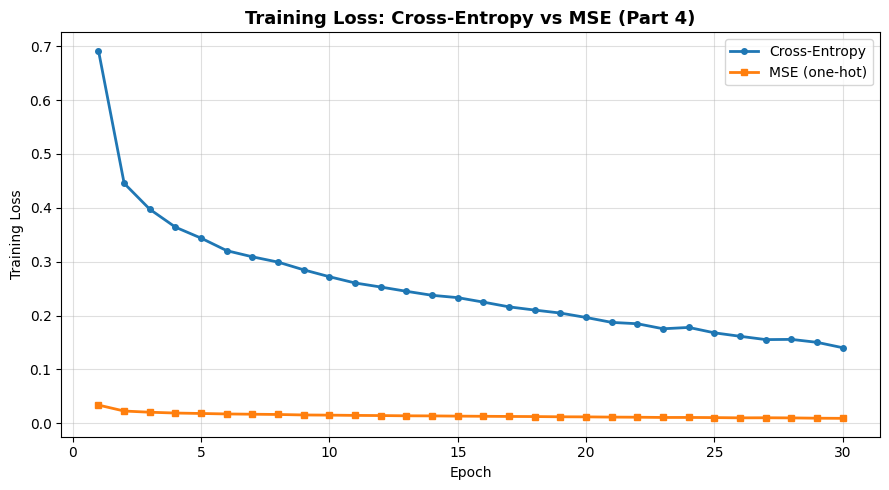

In [16]:
# 4.5  Train both
EPOCHS = 30
print("Training with Cross-Entropy...")
_, losses_ce,  acc_ce  = train_classifier("CE",  EPOCHS)

print("Training with MSE...")
_, losses_mse, acc_mse = train_classifier("MSE", EPOCHS)

print(f"\nTest Accuracy, Cross-Entropy : {acc_ce:.2f}%")
print(f"Test Accuracy, MSE           : {acc_mse:.2f}%")

# 4.6  Plot both training curves
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, EPOCHS+1), losses_ce,
        '-o', label="Cross-Entropy", linewidth=2, markersize=4)
ax.plot(range(1, EPOCHS+1), losses_mse,
        '-s', label="MSE (one-hot)", linewidth=2, markersize=4)
ax.set_title("Training Loss: Cross-Entropy vs MSE (Part 4)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("part4_loss_comparison.png", dpi=150)
plt.show()



In [19]:
# 4.7  regression -  California Housing Dataset
print("Regression Task")

# Load and split
housing      = fetch_california_housing()
X_reg, y_reg = housing.data, housing.target

X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

# Standardise features and targets
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_reg_tr = scaler_X.fit_transform(X_reg_tr)
X_reg_te = scaler_X.transform(X_reg_te)
y_reg_tr = scaler_y.fit_transform(y_reg_tr.reshape(-1,1)).ravel()
y_reg_te = scaler_y.transform(y_reg_te.reshape(-1,1)).ravel()
# tensors
Xr_tr = torch.tensor(X_reg_tr, dtype=torch.float32)
yr_tr = torch.tensor(y_reg_tr, dtype=torch.float32).unsqueeze(1)
Xr_te = torch.tensor(X_reg_te, dtype=torch.float32)
yr_te = torch.tensor(y_reg_te, dtype=torch.float32).unsqueeze(1)

reg_train_loader = DataLoader(TensorDataset(Xr_tr, yr_tr), batch_size=256, shuffle=True)

# 4.8  Regression MLP
class MLPRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)   
        )
    def forward(self, x):
        return self.net(x)
torch.manual_seed(SEED)
reg_model  = MLPRegressor()
reg_optim  = optim.Adam(reg_model.parameters(), lr=1e-3)
mse_crit   = nn.MSELoss()
for epoch in range(50):
    reg_model.train()
    for Xb, yb in reg_train_loader:
        reg_optim.zero_grad()
        mse_crit(reg_model(Xb), yb).backward()
        reg_optim.step()



Regression Task


In [20]:
# 4.9  Evaluate regression metrics
reg_model.eval()
with torch.no_grad():
    preds_scaled = reg_model(Xr_te).numpy()
    true_scaled  = yr_te.numpy()
# Inverse-transform back to original house-price scale
preds = scaler_y.inverse_transform(preds_scaled)
true  = scaler_y.inverse_transform(true_scaled)
mse  = np.mean((preds - true) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(preds - true))

print(f"Regression Test Metrics (California Housing)")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")

Regression Test Metrics (California Housing)
  MSE  : 0.2834
  RMSE : 0.5323
  MAE  : 0.3628


## 5. Part 4
